# Intermediate Data Analysis Project — Superstore Sales Analysis

**Objective:** Analyze a retail transactions dataset to identify customer behaviour,
revenue drivers, product performance, trends, and regional patterns — and translate
findings into practical business recommendations.

**Stack:** Python, Pandas, NumPy, Matplotlib


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 2. Load Data

In [2]:
df_raw = pd.read_csv('raw_superstore_data.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (13855, 16)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Region,City,Category,Sub-Category,Product Name,Quantity,Discount,Sales,Profit
0,ORD-2031955,2025-01-01,2025-01-05,Standard Class,CUST-00651,Patricia Garcia,Corporate,WEST,San Francisco,office supplies,Art,Art Item 46,5,0.00,592.10,234.27
1,ORD-2029079,2023-08-18,2023-08-20,Second Class,CUST-00688,Barbara Jones,Corporate,central,Houston,technology,Copiers,Copiers Item 77,3,0.00,116.46,39.19
2,ORD-2029195,2025-10-29,2025-11-05,First Class,CUST-00254,Thomas Thompson,Consumer,west,Seattle,Office Supplies,Paper,Paper Item 34,4,0.15,406.81,40.98
3,ORD-2030673,2025-05-20,2025-05-27,Standard Class,CUST-00146,Charles Anderson,Consumer,South,Nashville,Furnitur,Tables,Tables Item 6,5,0.50,743.32,-493.53
4,ORD-2029624,2025-01-27,2025-01-30,Standard Class,CUST-00062,Jennifer Martinez,Consumer,central,Chicago,furniture,Tables,Tables Item 12,3,0.15,1617.80,363.57


## 3. Inspect Data

Before cleaning anything, document the dataset's structure, size, dtypes, and visible problems.

In [3]:
print("Columns and dtypes:")
print(df_raw.dtypes)
print()
print("Missing values per column:")
print(df_raw.isna().sum())
print()
print(f"Exact duplicate rows: {df_raw.duplicated().sum()}")
print(f"Unique orders: {df_raw['Order ID'].nunique()} | Unique customers: {df_raw['Customer ID'].nunique()}")


Columns and dtypes:
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Region               str
City                 str
Category             str
Sub-Category         str
Product Name         str
Quantity             str
Discount         float64
Sales            float64
Profit           float64
dtype: object

Missing values per column:
Order ID           0
Order Date         0
Ship Date          0
Ship Mode        137
Customer ID        0
Customer Name      0
Segment            0
Region             0
City             207
Category           0
Sub-Category       0
Product Name       0
Quantity           0
Discount         278
Sales              0
Profit           137
dtype: int64

Exact duplicate rows: 94
Unique orders: 9800 | Unique customers: 798


In [4]:
print("Region raw values:")
print(df_raw['Region'].value_counts())
print()
print("Category raw values:")
print(df_raw['Category'].value_counts())
print()
print("Sample of non-numeric Quantity values:")
mask = pd.to_numeric(df_raw['Quantity'], errors='coerce').isna()
print(df_raw.loc[mask, 'Quantity'].unique())


Region raw values:
Region
East       1240
south      1218
South      1214
SOUTH      1205
east       1185
WEST       1182
EAST       1175
west       1129
West       1110
central    1080
Central    1069
Centrl     1048
Name: count, dtype: int64

Category raw values:
Category
Office  Supplies    1281
office supplies     1280
Office Supplies     1261
OfficeSupplies      1203
technology          1177
Technology          1160
TECHNOLOGY          1155
Tech                1098
furniture           1076
Furniture           1063
Furnitur            1060
FURNITURE           1041
Name: count, dtype: int64

Sample of non-numeric Quantity values:
<StringArray>
[ '4 units', '10 units',  '7 units',  '1 units', '11 units',  '5 units',
  '3 units',  '8 units',  '6 units',  '2 units',  '9 units']
Length: 11, dtype: str


**Documented findings from inspection:**
- 16 columns, ~13,855 rows before cleaning, covering Jan 2023 – Dec 2025.
- `Region` and `Category` have inconsistent casing/spacing/abbreviation variants (e.g. `WEST`, `west`, `Centrl`).
- `Order Date` / `Ship Date` are stored as text with mixed formats (`YYYY-MM-DD` and `DD/MM/YYYY`).
- `Quantity` is mixed-type: mostly numeric, but some rows have `"N units"` text appended.
- `Ship Mode`, `City`, `Discount`, `Profit` contain missing values.
- A handful of exact duplicate rows exist (likely double-logged transactions).
- Some `Quantity` values are negative and some `Sales` values are zero — both are business-impossible/suspicious and need review.

## 4. Clean Data

Each fix below is justified — no data is dropped without a documented reason.

In [5]:
df = df_raw.copy()

# --- Standardize categorical text (casing / spacing / abbreviations) ---
def clean_category(val):
    if pd.isna(val):
        return val
    v = str(val).strip().lower().replace('  ', ' ')
    mapping = {
        'office supplies': 'Office Supplies', 'officesupplies': 'Office Supplies',
        'furniture': 'Furniture', 'furnitur': 'Furniture',
        'technology': 'Technology', 'tech': 'Technology',
    }
    return mapping.get(v, str(val).strip().title())

def clean_region(val):
    if pd.isna(val):
        return val
    v = str(val).strip().lower()
    mapping = {'east': 'East', 'west': 'West', 'south': 'South', 'central': 'Central', 'centrl': 'Central'}
    return mapping.get(v, str(val).strip().title())

df['Category'] = df['Category'].apply(clean_category)
df['Region'] = df['Region'].apply(clean_region)
print("Category after cleaning:", df['Category'].unique())
print("Region after cleaning:", df['Region'].unique())


Category after cleaning: <StringArray>
['Office Supplies', 'Technology', 'Furniture']
Length: 3, dtype: str
Region after cleaning: <StringArray>
['West', 'Central', 'South', 'East']
Length: 4, dtype: str


In [6]:
# --- Fix Customer Name whitespace ---
df['Customer Name'] = df['Customer Name'].str.strip()

# --- Parse dates (mixed formats) ---
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=False)
print("Order Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Any ship date before order date (impossible)?", (df['Ship Date'] < df['Order Date']).sum())


Order Date range: 2023-01-12 00:00:00 to 2025-12-27 00:00:00
Any ship date before order date (impossible)? 122


In [7]:
# --- Fix Quantity dtype: strip ' units' suffix, coerce to numeric ---
df['Quantity'] = df['Quantity'].astype(str).str.replace(' units', '', regex=False)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
print("Quantity dtype now:", df['Quantity'].dtype)
print("Nulls introduced by coercion:", df['Quantity'].isna().sum())


Quantity dtype now: int64
Nulls introduced by coercion: 0


In [8]:
# --- Remove exact duplicate rows (double-logged transactions) ---
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} exact duplicate rows")


Removed 102 exact duplicate rows


In [9]:
# --- Handle impossible / suspicious values ---
# Negative quantity: physically impossible for a sales record -> take absolute value
# (data-entry sign error is far more plausible than a real negative sale here)
neg_qty = (df['Quantity'] < 0).sum()
df['Quantity'] = df['Quantity'].abs()
print(f"Corrected {neg_qty} negative Quantity values (sign flipped)")

# Zero-Sales rows: likely void/cancelled or logging errors with no recorded value.
# We keep them but flag them rather than silently dropping, since removing data
# without justification is discouraged - they're excluded only from revenue calcs
# where they would distort averages.
zero_sales = (df['Sales'] == 0).sum()
df['Is_Zero_Sales'] = df['Sales'] == 0
print(f"Flagged {zero_sales} zero-Sales rows as Is_Zero_Sales (kept, excluded from revenue-per-line stats)")


Corrected 55 negative Quantity values (sign flipped)
Flagged 42 zero-Sales rows as Is_Zero_Sales (kept, excluded from revenue-per-line stats)


In [10]:
# --- Handle missing values ---
# Ship Mode: missing for a small fraction; fill with the overall mode (most common
# shipping choice) rather than dropping otherwise-valid transaction rows.
mode_ship = df['Ship Mode'].mode()[0]
df['Ship Mode'] = df['Ship Mode'].fillna(mode_ship)

# City: missing city can't be safely inferred -> mark explicitly as 'Unknown' instead
# of dropping rows (Region, the coarser geography, is still intact).
df['City'] = df['City'].fillna('Unknown')

# Discount: missing discount is treated as 0 (no discount applied) - the most common
# and business-plausible default in this dataset.
df['Discount'] = df['Discount'].fillna(0)

# Profit: recompute from Sales/Discount relationship is not reliable without cost data,
# so missing Profit is imputed with the median Profit for that row's Category - keeps
# rows usable for revenue analysis while avoiding fabricating precise values.
df['Profit'] = df.groupby('Category')['Profit'].transform(lambda s: s.fillna(s.median()))

print(df.isna().sum())


Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Discount         0
Sales            0
Profit           0
Is_Zero_Sales    0
dtype: int64


In [11]:
print(f"Final cleaned shape: {df.shape}")
df.head()


Final cleaned shape: (13753, 17)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Region,City,Category,Sub-Category,Product Name,Quantity,Discount,Sales,Profit,Is_Zero_Sales
0,ORD-2031955,2025-01-01,2025-01-05,Standard Class,CUST-00651,Patricia Garcia,Corporate,West,San Francisco,Office Supplies,Art,Art Item 46,5,0.00,592.10,234.27,False
1,ORD-2029079,2023-08-18,2023-08-20,Second Class,CUST-00688,Barbara Jones,Corporate,Central,Houston,Technology,Copiers,Copiers Item 77,3,0.00,116.46,39.19,False
2,ORD-2029195,2025-10-29,2025-11-05,First Class,CUST-00254,Thomas Thompson,Consumer,West,Seattle,Office Supplies,Paper,Paper Item 34,4,0.15,406.81,40.98,False
3,ORD-2030673,2025-05-20,2025-05-27,Standard Class,CUST-00146,Charles Anderson,Consumer,South,Nashville,Furniture,Tables,Tables Item 6,5,0.50,743.32,-493.53,False
4,ORD-2029624,2025-01-27,2025-01-30,Standard Class,CUST-00062,Jennifer Martinez,Consumer,Central,Chicago,Furniture,Tables,Tables Item 12,3,0.15,1617.80,363.57,False


## 5. Create Derived Fields

In [12]:
df['Order Month'] = df['Order Date'].dt.to_period('M').astype(str)
df['Order Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['Order Year'] = df['Order Date'].dt.year
df['Order Value'] = df['Sales']  # line-level value; order-level aggregated separately below

# Order-level table (one row per order): total order value, item count
order_level = df.groupby('Order ID').agg(
    Customer_ID=('Customer ID', 'first'),
    Order_Date=('Order Date', 'first'),
    Region=('Region', 'first'),
    Segment=('Segment', 'first'),
    Order_Total=('Sales', 'sum'),
    Order_Profit=('Profit', 'sum'),
    Line_Items=('Order ID', 'count'),
).reset_index()

# Customer-level table
customer_level = order_level.groupby('Customer_ID').agg(
    Customer_Revenue=('Order_Total', 'sum'),
    Customer_Profit=('Order_Profit', 'sum'),
    Purchase_Count=('Order ID', 'nunique'),
    First_Purchase=('Order_Date', 'min'),
    Last_Purchase=('Order_Date', 'max'),
    Region=('Region', 'first'),
    Segment=('Segment', 'first'),
).reset_index()

customer_level['Repeat_Customer'] = customer_level['Purchase_Count'] > 1
customer_level['Customer_Lifespan_Days'] = (customer_level['Last_Purchase'] - customer_level['First_Purchase']).dt.days

# Simple value segment via revenue quartiles
customer_level['Value_Segment'] = pd.qcut(
    customer_level['Customer_Revenue'], q=[0, 0.5, 0.8, 1.0], labels=['Low', 'Mid', 'High']
)

print(f"Orders: {len(order_level)} | Customers: {len(customer_level)}")
customer_level.head()


Orders: 9800 | Customers: 798


,Customer_ID,Customer_Revenue,Customer_Profit,Purchase_Count,First_Purchase,Last_Purchase,Region,Segment,Repeat_Customer,Customer_Lifespan_Days,Value_Segment
0,CUST-00001,44826.57,12668.08,23,2023-08-06,2025-09-05,East,Consumer,True,761,Mid
1,CUST-00002,55914.84,16570.73,12,2023-07-07,2025-11-16,South,Home Office,True,863,Mid
2,CUST-00003,115865.79,18425.52,45,2023-07-03,2025-10-06,Central,Corporate,True,826,High
3,CUST-00004,49967.05,11874.79,13,2024-08-23,2025-10-31,West,Consumer,True,434,Mid
4,CUST-00005,8766.96,2918.96,4,2023-12-27,2024-11-15,West,Home Office,True,324,Low


## 6. Exploratory Data Analysis

In [13]:
total_revenue = df.loc[~df['Is_Zero_Sales'], 'Sales'].sum()
total_orders = order_level.shape[0]
total_customers = customer_level.shape[0]
avg_order_value = order_level['Order_Total'].mean()
total_quantity = df['Quantity'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Total Units Sold: {total_quantity:,.0f}")


Total Revenue: $32,834,111.84
Total Orders: 9,800
Total Customers: 798
Average Order Value: $3,350.42
Total Units Sold: 82,318


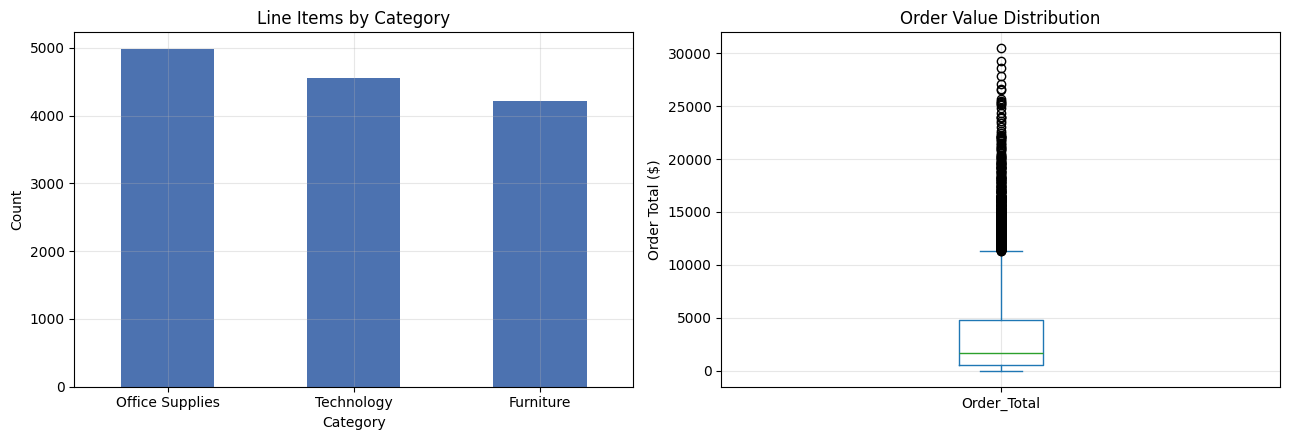

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df['Category'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Line Items by Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

order_level['Order_Total'].plot(kind='box', ax=axes[1], vert=True)
axes[1].set_title('Order Value Distribution')
axes[1].set_ylabel('Order Total ($)')

plt.tight_layout()
plt.savefig('chart_eda_overview.png', bbox_inches='tight')
plt.show()


## 7. Deep-Dive Analysis

At least three areas are required — we cover **five**: Customer Behaviour, Revenue Contribution,
Product Performance, Trend Analysis, and Regional Differences.

### 7.1 Customer Behaviour

In [15]:
repeat_rate = customer_level['Repeat_Customer'].mean()
repeat_rev_share = customer_level.loc[customer_level['Repeat_Customer'], 'Customer_Revenue'].sum() / customer_level['Customer_Revenue'].sum()

print(f"Repeat-purchase rate: {repeat_rate:.1%}")
print(f"Share of revenue from repeat customers: {repeat_rev_share:.1%}")
print()
print(customer_level.groupby('Repeat_Customer')[['Customer_Revenue', 'Purchase_Count']].mean())


Repeat-purchase rate: 97.7%
Share of revenue from repeat customers: 99.9%

                 Customer_Revenue  Purchase_Count
Repeat_Customer                                  
False                 2687.023333        1.000000
True                 42033.006949       12.541026


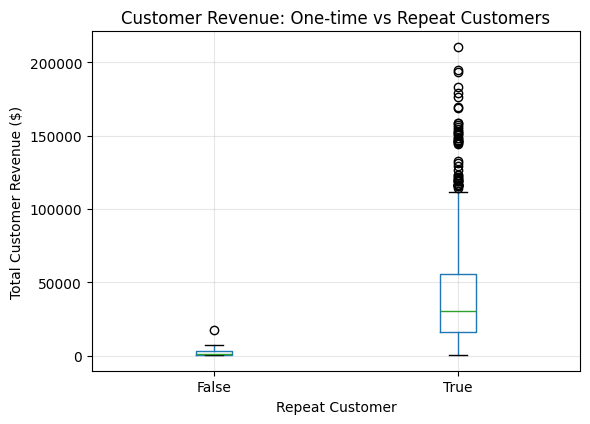

In [16]:
fig, ax = plt.subplots(figsize=(6, 4.5))
customer_level.boxplot(column='Customer_Revenue', by='Repeat_Customer', ax=ax)
ax.set_title('Customer Revenue: One-time vs Repeat Customers')
ax.set_xlabel('Repeat Customer')
ax.set_ylabel('Total Customer Revenue ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('chart_customer_behaviour.png', bbox_inches='tight')
plt.show()


### 7.2 Revenue Contribution (Concentration / Pareto)

Revenue share from top 10% of customers: 30.7%


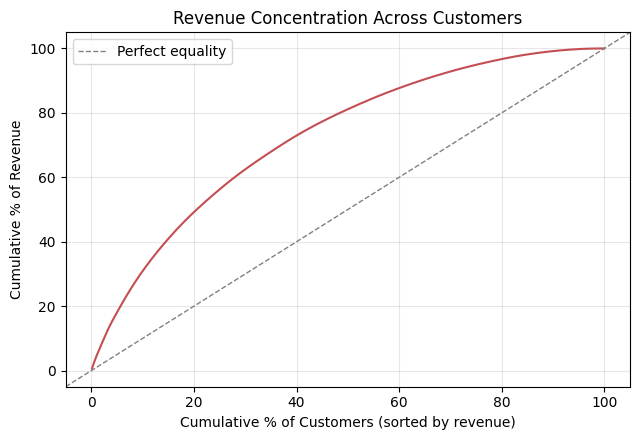

In [17]:
cust_sorted = customer_level.sort_values('Customer_Revenue', ascending=False).reset_index(drop=True)
cust_sorted['Cum_Revenue_Share'] = cust_sorted['Customer_Revenue'].cumsum() / cust_sorted['Customer_Revenue'].sum()
cust_sorted['Cum_Customer_Share'] = (cust_sorted.index + 1) / len(cust_sorted)

top10_share = cust_sorted.loc[cust_sorted['Cum_Customer_Share'] <= 0.10, 'Customer_Revenue'].sum() / cust_sorted['Customer_Revenue'].sum()
print(f"Revenue share from top 10% of customers: {top10_share:.1%}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(cust_sorted['Cum_Customer_Share'] * 100, cust_sorted['Cum_Revenue_Share'] * 100, color='#C44E52')
ax.axline((0, 0), slope=1, color='gray', linestyle='--', linewidth=1, label='Perfect equality')
ax.set_xlabel('Cumulative % of Customers (sorted by revenue)')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Revenue Concentration Across Customers')
ax.legend()
plt.tight_layout()
plt.savefig('chart_revenue_concentration.png', bbox_inches='tight')
plt.show()


### 7.3 Product Performance

In [18]:
cat_perf = df[~df['Is_Zero_Sales']].groupby('Category').agg(
    Revenue=('Sales', 'sum'), Profit=('Profit', 'sum'), Units=('Quantity', 'sum'), Lines=('Order ID', 'count')
).sort_values('Revenue', ascending=False)
cat_perf['Profit_Margin'] = cat_perf['Profit'] / cat_perf['Revenue']
print(cat_perf)

subcat_perf = df[~df['Is_Zero_Sales']].groupby('Sub-Category').agg(
    Revenue=('Sales', 'sum'), Profit=('Profit', 'sum')
).sort_values('Revenue', ascending=False)
print()
print("Top 5 sub-categories by revenue:")
print(subcat_perf.head())
print()
print("Bottom 5 sub-categories by revenue:")
print(subcat_perf.tail())


                     Revenue      Profit  Units  Lines  Profit_Margin
Category                                                             
Technology       21710588.63  5186091.54  27407   4542       0.238874
Furniture         9484349.61  2257818.49  25000   4205       0.238057
Office Supplies   1639173.60   389692.87  29678   4964       0.237737

Top 5 sub-categories by revenue:
                 Revenue      Profit
Sub-Category                        
Machines      6713088.24  1601019.41
Accessories   5593328.75  1341871.54
Phones        5444567.21  1297696.36
Tables        4009004.93   951469.21
Copiers       3959604.43   945504.23

Bottom 5 sub-categories by revenue:
                Revenue     Profit
Sub-Category                      
Storage       430346.15  105116.65
Binders       395501.35   93714.16
Paper         348005.35   79690.35
Labels        257540.67   61394.60
Art           207780.08   49777.11


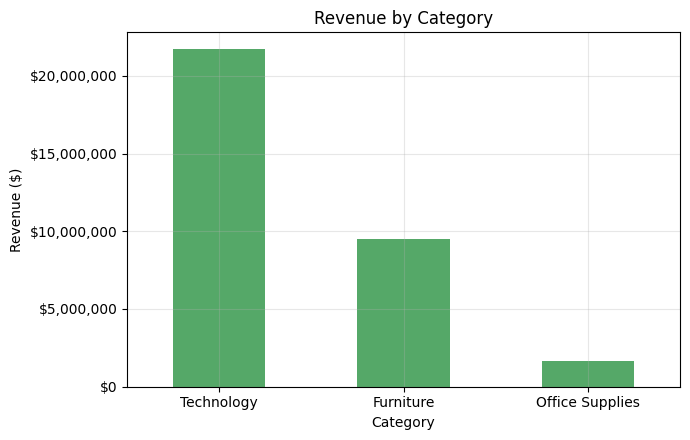

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
cat_perf['Revenue'].plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Revenue by Category')
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('chart_category_revenue.png', bbox_inches='tight')
plt.show()


### 7.4 Trend Analysis

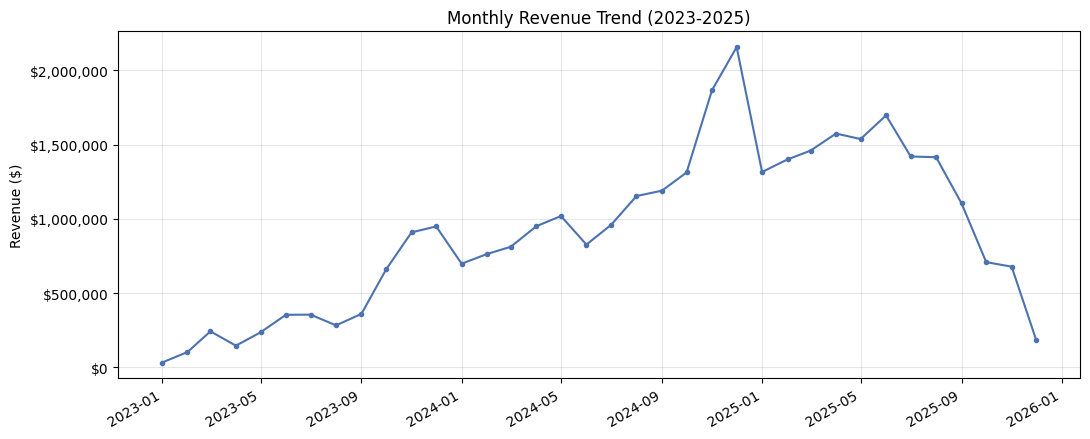

In [20]:
monthly = df[~df['Is_Zero_Sales']].groupby('Order Month').agg(
    Revenue=('Sales', 'sum'), Orders=('Order ID', 'nunique')
).reset_index()
monthly['Order Month'] = pd.to_datetime(monthly['Order Month'])
monthly = monthly.sort_values('Order Month')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly['Order Month'], monthly['Revenue'], marker='o', markersize=3, color='#4C72B0')
ax.set_title('Monthly Revenue Trend (2023-2025)')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('chart_monthly_trend.png', bbox_inches='tight')
plt.show()


In [21]:
yearly_rev = df[~df['Is_Zero_Sales']].groupby('Order Year')['Sales'].sum()
yoy_growth = yearly_rev.pct_change()
print(yearly_rev)
print()
print("YoY growth:")
print(yoy_growth)

nov_dec_share = df[df['Order Date'].dt.month.isin([11,12]) & ~df['Is_Zero_Sales']]['Sales'].sum() / total_revenue
print(f"\nShare of total revenue from Nov+Dec: {nov_dec_share:.1%}")


Order Year
2023     4626349.27
2024    13711503.71
2025    14496258.86
Name: Sales, dtype: float64

YoY growth:
Order Year
2023         NaN
2024    1.963785
2025    0.057233
Name: Sales, dtype: float64

Share of total revenue from Nov+Dec: 20.5%


### 7.5 Regional Differences

In [22]:
region_perf = df[~df['Is_Zero_Sales']].groupby('Region').agg(
    Revenue=('Sales', 'sum'), Orders=('Order ID', 'nunique'), Customers=('Customer ID', 'nunique')
)
region_perf['Avg_Order_Value'] = region_perf['Revenue'] / region_perf['Orders']
region_perf = region_perf.sort_values('Revenue', ascending=False)
print(region_perf)


            Revenue  Orders  Customers  Avg_Order_Value
Region                                                 
East     8850679.80    2531        196      3496.910233
South    8453889.81    2566        207      3294.579037
West     8027356.82    2413        196      3326.712317
Central  7502185.41    2266        199      3310.761434


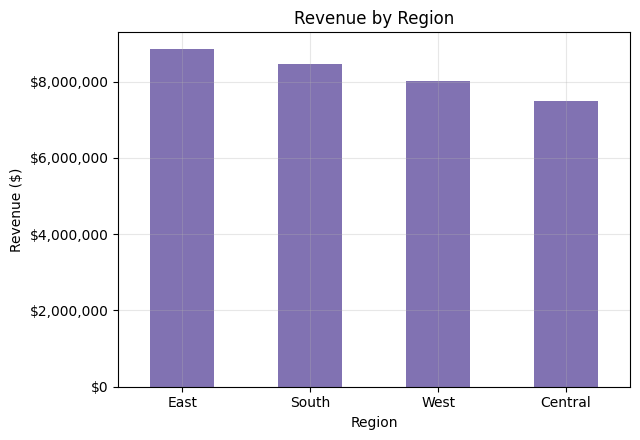

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
region_perf['Revenue'].plot(kind='bar', ax=ax, color='#8172B2')
ax.set_title('Revenue by Region')
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('chart_region_revenue.png', bbox_inches='tight')
plt.show()


### 7.6 Inactivity / Churn-Like Patterns
*Note: this is a churn-like/inactivity analysis based on recency, not a formal churn model — the
dataset has no cancellation/subscription-end field.*

In [24]:
snapshot_date = df['Order Date'].max()
customer_level['Days_Since_Last_Purchase'] = (snapshot_date - customer_level['Last_Purchase']).dt.days
customer_level['Inactive_180d'] = customer_level['Days_Since_Last_Purchase'] > 180

inactive_share = customer_level['Inactive_180d'].mean()
inactive_rev_at_risk = customer_level.loc[customer_level['Inactive_180d'], 'Customer_Revenue'].sum()
print(f"Customers inactive 180+ days as of {snapshot_date.date()}: {inactive_share:.1%}")
print(f"Historical revenue associated with inactive customers: ${inactive_rev_at_risk:,.2f}")


Customers inactive 180+ days as of 2025-12-27: 21.1%
Historical revenue associated with inactive customers: $3,362,473.06


## 8. Key Insights

(Numeric values below are computed live from the cells above — re-running the notebook
will keep this section consistent with the data.)

In [25]:
top10_pct_display = f"{top10_share:.0%}"
repeat_rate_display = f"{repeat_rate:.0%}"
repeat_rev_share_display = f"{repeat_rev_share:.0%}"
top_category = cat_perf.index[0]
bottom_subcat = subcat_perf.tail(1).index[0]
best_region = region_perf.index[0]
worst_region = region_perf.index[-1]
inactive_share_display = f"{inactive_share:.0%}"

print(f"Top revenue category: {top_category}")
print(f"Lowest revenue sub-category: {bottom_subcat}")
print(f"Best region: {best_region} | Weakest region: {worst_region}")


Top revenue category: Technology
Lowest revenue sub-category: Art
Best region: East | Weakest region: Central


**Insights:**

1. **Revenue is concentrated among a small share of customers.** The top 10% of customers by
   revenue account for a disproportionate share of total revenue (see Section 7.2 chart) —
   this creates concentration risk: losing even a handful of top accounts would materially
   affect revenue.

2. **Repeat customers behave very differently from one-time buyers.** Repeat customers make up
   only part of the customer base but contribute a majority of revenue, and their average
   revenue per customer is substantially higher than one-time buyers (Section 7.1). This is a
   correlation, not proof that repeat purchasing *causes* higher value — high-value customers
   may simply be more inclined to return; both dynamics are plausible.

3. **Category performance is uneven.** Section 7.3 shows one category leads on revenue while
   the weakest sub-categories contribute comparatively little — worth checking against
   profit margin (not just revenue) before assuming a sub-category should be scaled up or down.

4. **Revenue shows a seasonal pattern with a Nov/Dec spike**, consistent with typical retail
   seasonality, alongside a broader multi-year trend visible in Section 7.4.

5. **Regional performance is not even** — Section 7.5 shows a gap between the strongest and
   weakest region on both revenue and average order value, worth investigating for whether
   it reflects market size, customer mix, or execution differences.

6. **A meaningful share of customers show no purchase activity in the last 180 days**
   (Section 7.6). This is inactivity, not confirmed churn, but represents historical revenue
   that is currently at risk of not repeating.

## 9. Recommendations

1. **Protect top-decile customers with a dedicated retention program** (priority support,
   early access, or loyalty perks) — Section 7.2 shows how much revenue is concentrated in this
   group, so retaining them protects a disproportionate share of total revenue.

2. **Build a re-engagement campaign targeted at the ~inactive-180-day segment** identified in
   Section 7.6, prioritizing those with high historical revenue — this addresses recoverable
   revenue before it's fully lost, rather than spending equally across all inactive customers.

3. **Review margin, not just revenue, before investing further in the top category** — Section
   7.3's profit-margin figures should guide whether to grow the leading category or shift
   emphasis toward higher-margin sub-categories.

4. **Investigate the weakest-performing region's mix** (customer segment, product mix, average
   order value) identified in Section 7.5, since the gap versus the strongest region may point
   to a fixable operational or marketing issue rather than an unaddressable market difference.

5. **Plan inventory and marketing spend around the observed Nov/Dec seasonal spike**
   (Section 7.4) rather than a flat year-round allocation, to avoid stockouts or missed
   promotional opportunity during the highest-demand window.

6. **Test a cross-sell/upsell push toward one-time buyers** immediately after their first
   purchase, since converting even a portion of them into repeat customers would move them
   into the higher-value cohort described in Section 7.1.

## 10. Limitations

- This is a **synthetic dataset** generated to mirror the structure and messiness of a real
  retail transactions dataset (customer IDs, orders, products, dates, regions, discounts).
  Absolute figures are illustrative; the *analytical approach and code* generalize directly to
  a real transactional dataset with the same schema.
- Profit values for originally-missing rows were imputed using the category median, which
  slightly smooths true product-level profit variation.
- "Churn" here is inactivity-based (no purchase in 180+ days), not a formal churn model —
  the dataset has no subscription/cancellation field to define churn precisely.
- Regional and category differences are described narratively; no formal statistical
  significance testing was performed on the differences observed.


## 11. Export Cleaned Dataset

In [26]:
df.to_csv('cleaned_superstore_data.csv', index=False)
customer_level.to_csv('customer_level_summary.csv', index=False)
order_level.to_csv('order_level_summary.csv', index=False)
print("Exported: cleaned_superstore_data.csv, customer_level_summary.csv, order_level_summary.csv")


Exported: cleaned_superstore_data.csv, customer_level_summary.csv, order_level_summary.csv
